# Project Overview: Telco Customer Churn
---

**Group Alpha:**
- Amira Aqila Afdhal
- Christian
- Ditya Ayu Anjani

---

# Problem Understanding
---

## Problem Statement
| No | Problem Statement |
|----|-------------------|
| 1 | Can we predict whether a customer will churn based on data set? |
| 2 | How can we improve the product to keep our customers loyal? |
| 3 | How can we improve the product to keep our customers loyal? |

## Stakeholder
| Stakeholder | Description |
|-----|-----|
| Customer Retention Team |  Uses churn prediction to create targeted retention strategies |

## Goals

| No | Goals |
|----|-------------------|
| 1 | Predict Churn: Build a machine learning model to accurately classify customers likely to churn |
| 2 | Identify Churn Drivers: Understand which features (e.g., contract type, internet service, payment method) most influence churn |
| 3 | Customer Segmentation: Group customers based on similar usage patterns and risk levels |
| 4 | Optimize Retention Efforts: Enable targeted campaigns with data-driven interventions |

## Evaluation Metic
Target variable:

`1` = Customer `churn` (discontinues subscription)

`0` = Customer `stay`

**Confusion Matrix**
|                             | Prediction: Customer churns (1) | Prediksi: Customer stays (0) |
|-----------------------------|---------------------|----------------------------|
| **Actual: Customer churns (1)**       | True Positive (TP)  | False Negative (FN)        |
| **Actual: Customer stays (0)** | False Positive (FP) | True Negative (TN)         |


- **True Positive (TP)**: Customer actually churns and the model correctly predicts churn
- **False Positive (FP)**: Customer does not churn, but the model predicts churn → might trigger unnecessary retention efforts
- **False Negative (FN)**: Customer actually churns, but the model predicts no churn → risk of unexpected revenue loss
- **True Negative (TN)**: Customer does not churn and the model correctly predicts no churn

### Main focus: Minimize False Negatives (FN)
Since missing actual churners can lead to revenue loss and lower retention rate

Key metrics:
- **Recall**: Measures how many churners are correctly identified by the model\
  **Recall = $ \frac{TP}{TP + FN} $**
- **ROC AUC (Receiver Operating Characteristic - Area Under Curve)**: Evaluates the model's ability to distinguish churn vs no churn. A higher AUC indicates better discrimination between classes

- **F<sub>β</sub> Score**: A weighted harmonic mean of precision and recall, where β determines the importance of recall relative to precision
  - Commonly used to emphasize recall in churn prediction scenarios
  - **F<sub>1</sub> Score** (β=1) balances precision and recall equally
  - **F<sub>2</sub> Score** (β=2) puts more emphasis on recall


---

# Import Libraries
---

In [1]:
# Basic
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
# pd.set_option("display.max_columns", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_colwidth", 200)

# Test
from scipy.stats import normaltest, chi2_contingency, ttest_ind
from scipy import stats

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectPercentile

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb

# Evaluation
from sklearn.model_selection import (
    cross_validate,
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
    cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (
    make_scorer,
    fbeta_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
)
from sklearn.metrics import roc_auc_score, RocCurveDisplay

import pickle

---

# Data Understanding
Data source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---

## Read Data Set

<div class="alert alert-info" role="alert">Read the main dataset that was provided at the beginning of the final project.</div>

In [2]:
base = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
base

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


<div class="alert alert-info" role="alert">Read the status dataset that was found on the internet.</div>

In [3]:
status = pd.read_csv("dataset/Tambahan/Telco_customer_churn_status.csv", sep=";")
status = status[["Customer ID", "Satisfaction Score", "CLTV", "Churn Reason"]]
status

,Customer ID,Satisfaction Score,CLTV,Churn Reason
0,8779-QRDMV,3,5433,Competitor offered more data
1,7495-OOKFY,3,5302,Competitor made better offer
2,1658-BYGOY,2,3179,Competitor made better offer
3,4598-XLKNJ,2,5337,Limited range of services
4,4846-WHAFZ,2,2793,Extra data charges
...,...,...,...,...
7038,2569-WGERO,5,5306,NaN
7039,6840-RESVB,3,2140,NaN
7040,2234-XADUH,4,5560,NaN
7041,4801-JZAZL,4,2793,NaN


<div class="alert alert-info" role="alert">Read the demographics dataset that was found on the internet.</div>

In [4]:
demographic = pd.read_csv(
    "dataset/Tambahan/Telco_customer_churn_demographics.csv", sep=";"
)
demographic = demographic[["Customer ID", "Under 30"]]
demographic

,Customer ID,Under 30
0,8779-QRDMV,No
1,7495-OOKFY,No
2,1658-BYGOY,No
3,4598-XLKNJ,No
4,4846-WHAFZ,No
...,...,...
7038,2569-WGERO,No
7039,6840-RESVB,No
7040,2234-XADUH,No
7041,4801-JZAZL,No


<div class="alert alert-info" role="alert">Merge all the prepared datasets.</div>

In [5]:
# Join all table
df = base.merge(status, left_on="customerID", right_on="Customer ID", how="left").merge(
    demographic, left_on="customerID", right_on="Customer ID", how="left"
)

df = df[
    [
        "customerID",
        "gender",
        "Under 30",
        "SeniorCitizen",
        "Partner",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "CLTV",
        "Satisfaction Score",
        "Churn Reason",
        "Churn",
    ]
]

df.sample(5)

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,CLTV,Satisfaction Score,Churn Reason,Churn
2694,2466-NEJOJ,Male,No,0,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),8,19.65,169.75,4535,4,NaN,No
6939,2758-RNWXS,Male,No,0,No,Yes,No,Fiber optic,Yes,No,No,Yes,No,Yes,One year,Yes,Electronic check,35,89.20,3251.3,4446,4,NaN,No
377,9601-BRXPO,Female,No,0,Yes,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),25,104.95,2566.5,3642,3,Competitor made better offer,Yes
2269,0151-ONTOV,Female,No,0,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,1,70.90,70.9,4739,1,Competitor had better devices,Yes
6408,5748-RNCJT,Male,No,0,No,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),69,106.50,7348.8,4859,3,Competitor offered higher download speeds,Yes


### Feature Information

| Feature Name        | Description |
|---------------------|-------------|
| customerID          | Unique identifier for each customer |
| gender              | Customer"s gender |
| Under 30            | Whether the customer is under 30 years old |
| SeniorCitizen       | Whether the customer is a senior citizen (1 = Yes, 0 = No) |
| Partner             | Whether the customer has a partner |
| PhoneService        | Whether the customer has phone service |
| MultipleLines       | Whether the customer has multiple phone lines |
| InternetService     | Type of internet service (DSL, Fiber optic, None) |
| OnlineSecurity      | Whether the customer has online security service |
| OnlineBackup        | Whether the customer has online backup service |
| DeviceProtection    | Whether the customer has device protection service |
| TechSupport         | Whether the customer has tech support service |
| StreamingTV         | Whether the customer has streaming TV service |
| StreamingMovies     | Whether the customer has streaming movie service |
| Contract            | Customer"s contract type (Month-to-month, One year, Two year) |
| PaperlessBilling    | Whether the customer is on paperless billing |
| PaymentMethod       | Customer"s payment method (e.g., Electronic check, Mailed check) |
| tenure              | Number of months the customer has stayed with the company |
| MonthlyCharges      | The amount charged to the customer monthly |
| TotalCharges        | The total amount charged to the customer |
| CLTV                | Customer Lifetime Value |
| Satisfaction Score  | Customer satisfaction rating |
| Churn Reason        | Reason the customer churned |
| Churn               | Whether the customer churned (Yes or No) |

### Feature Grouping

| Customer Profile | Service Subscription | Account & Billing | Customer Value & Satisfaction | Churn Outcome |
|--------------|--------------|--------------|--------------|--------------|
| customerID | PhoneService | Contract | CLTV | Churn |
| gender | MultipleLines | PaperlessBilling | Population | Churn Reason |
| Under 30 | InternetService | PaymentMethod |  |  |
| SeniorCitizen | OnlineSecurity | MonthlyCharges |  |  |
| Partner | OnlineBackup | TotalCharges |  |  |
|  | DeviceProtection | Tenure |  |  |
|  | TechSupport |  |  |  |
|  | StreamingTv |  |  |  |
|  | StreamingMovies |  |  |  |

#### Numerical Features
Numerical Features
The following features are numeric and can be used in statistical analysis and modeling:

- `SeniorCitizen`  
- `tenure`  
- `MonthlyCharges`
- `CLTV`  
- `Satisfaction Score`

#### Categorical Features
These features are categorical, representing labels or categories (including binary yes/no and multi-class):

- `customerID`
- `gender`
- `Under 30`
- `Partner`
- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`
- `TotalCharges` *(currently detected as categorical, should be converted to numeric)*
- `Churn Reason`

#### Target Variable
- `Churn` — Indicates whether the customer has churned (`Yes` or `No`)

---

## Data Profiling

<div class="alert alert-info" role="alert">Create a DataFrame to check for missing values, outliers, invalid entries, or incorrect data types.</div>

In [6]:
df_unique = pd.DataFrame(
    {
        "Features": df.columns.values,
        "Data Type": df.dtypes.values,
        "Data Count": df.count().values,
        "Null Value Count": df.isnull().sum().values,
        "Number of Unique Value": df.nunique().values,
        "Unique Value": [df[col].unique() for col in df.columns],
    }
)


print("Unique Table:")
display(df_unique)

# dataframe information
print(f"Total Rows           :", df.shape[0])
print(f"Total Columns        :", df.shape[1])

print("-----------------------------\nData Types Count     :")
print(df.dtypes.value_counts())

Unique Table:


,Features,Data Type,Data Count,Null Value Count,Number of Unique Value,Unique Value
0,customerID,object,7043,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-HQITU, 9305-CDSKC, 1452-KIOVK, 6713-OKOMC, 7892-POOKP, 6388-TABGU, 9763-GRSKD, 7469-LKBCI, 8091-TTVAX, 0280-XJGEX, 5129-JLPIS, 3655-SNQYZ, 819..."
1,gender,object,7043,0,2,"[Female, Male]"
2,Under 30,object,7043,0,2,"[No, Yes]"
3,SeniorCitizen,int64,7043,0,2,"[0, 1]"
4,Partner,object,7043,0,2,"[Yes, No]"
5,PhoneService,object,7043,0,2,"[No, Yes]"
6,MultipleLines,object,7043,0,3,"[No phone service, No, Yes]"
7,InternetService,object,7043,0,3,"[DSL, Fiber optic, No]"
8,OnlineSecurity,object,7043,0,3,"[No, Yes, No internet service]"
9,OnlineBackup,object,7043,0,3,"[Yes, No, No internet service]"


Total Rows           : 7043
Total Columns        : 24
-----------------------------
Data Types Count     :
object     19
int64       4
float64     1
Name: count, dtype: int64


<div class="alert alert-danger" role="alert">The TotalCharges column contains empty spaces (" ") and its data type is object. Convert it to a numeric type. Also, convert the following columns to boolean: Under 30, Partner, PhoneService, and Churn.</div>

<div class="alert alert-info" role="alert">Check numeric columns for any invalid entries, such as negative numbers.</div>

In [7]:
# Check invalid value
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,CLTV,Satisfaction Score
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,4400.295755,3.244924
std,0.368612,24.559481,30.090047,1183.057152,1.201657
min,0.000000,0.000000,18.250000,2003.000000,1.000000
25%,0.000000,9.000000,35.500000,3469.000000,3.000000
50%,0.000000,29.000000,70.350000,4527.000000,3.000000
75%,0.000000,55.000000,89.850000,5380.500000,4.000000
max,1.000000,72.000000,118.750000,6500.000000,5.000000


<div class="alert alert-success">There are no invalid values in the numerical columns.</div>

## Identify missing value, invalid, outlier, and duplicate

### Missing Value

<div class="alert alert-info" role="alert">Check how many row effected by missing values.</div>

In [8]:
pd.DataFrame(round(df.isna().sum() / len(df) * 100, 2).astype(str) + "%").rename(
    columns={0: "Missing Value"}
)

,Missing Value
customerID,0.0%
gender,0.0%
Under 30,0.0%
SeniorCitizen,0.0%
Partner,0.0%
PhoneService,0.0%
MultipleLines,0.0%
InternetService,0.0%
OnlineSecurity,0.0%
OnlineBackup,0.0%


<div class="alert alert-danger">Fill the Churn Reason column with "-". The column is empty because the customer did not churn.</div>

### Invalid Value

<div class="alert alert-info" role="alert">Check how many row effected by invalid values.</div>

In [9]:
pd.DataFrame(
    round(
        df[df["TotalCharges"] == " "][["TotalCharges"]].count() / len(df) * 100, 2
    ).astype(str)
    + "%"
).rename(columns={0: "Invalid Value"})

,Invalid Value
TotalCharges,0.16%


<div class="alert alert-danger">Drop the invalid values as they represent just 0.16%</div>

### Outlier

<div class="alert alert-info" role="alert">Check how many rows are affected by outliers using the following rule:<br>
"Values greater than Q3 + 1.5 × IQR (Interquartile Range) or less than Q1 − 1.5 × IQR are considered outliers."
</div>

In [10]:
outlier_counts = {}
for col in df.select_dtypes(include=[np.number]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame.from_dict(
    outlier_counts, orient="index", columns=["Outlier Count"]
)
outlier_df = outlier_df[outlier_df["Outlier Count"] > 0]

outlier_df.sort_values(by="Outlier Count", ascending=False)

,Outlier Count
SeniorCitizen,1142
Satisfaction Score,922


<div class="alert alert-danger">Handle outliers using clipping, log-transform, or robust scaling.</div>

### Duplicate

<div class="alert alert-info" role="alert">Check how many row have duplicate</div>

In [11]:
pd.DataFrame(df.duplicated().value_counts())

,count
False,7043


<div class="alert alert-success">There are no duplicates</div>

## Conclusion To Do

**Convert:**
  * `SeniorCitizen` → to **categorical**
  * `Number of Dependents`, `Satisfaction Score` → to **ordinal or categorical**

**Transform and scale:**
  * `tenure`, `Population`, `CLTV` → **log transform**, then **scale**
  * `MonthlyCharges` → **scale** (StandardScaler or RobustScaler)

**Correlated features:**
  * Keep features like `tenure`, `CLTV`, and `Satisfaction Score`
  * Explore **feature interactions** (e.g., `tenure` & `CLTV`, `SeniorCitizen` & `MonthlyCharges`)
  * Monitor **multicollinearity** in correlated pairs

**Handle categorical cardinality:**
  * Drop `customerID` (identifier)
  * `City` → **group or frequency encode**
  * `Churn Reason`, `PaymentMethod`, `OnlineBackup` → **one-hot encode**

**Data quality:**
  * **Impute or drop** columns with missing values
  * Handle outliers using **clipping**, **log transformation**, or **robust scaling**

---

# Preprocessing
---

## Data Cleansing

<div class="alert alert-danger" role="alert">Fill missing churn reason with "-"</div>

In [12]:
df["Churn Reason"] = df["Churn Reason"].fillna("-")

<div class="alert alert-danger" role="alert">Remove rows where TotalCharges is equal to " ".</div>

In [13]:
df = df[df["TotalCharges"] != " "]

## Data Transformation

In [14]:
cols = [
    "Under 30",
    "Partner",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
]

for col in cols:
    df[col] = df[col].map({"No": False, "Yes": True})

cols = [
    "SeniorCitizen",
]

for col in cols:
    df[col] = df[col].map({0: False, 1: True})

<div class="alert alert-danger" role="alert">Convert columns to boolean</div>

In [15]:
df[["MonthlyCharges", "TotalCharges"]] = df[["MonthlyCharges", "TotalCharges"]].astype(
    float
)

<div class="alert alert-danger" role="alert">Change data type from int to float</div>

## Create Column

<div class="alert alert-info" role="alert">Create Feature AgeGroup</div>

In [16]:
df["AgeGroup"] = pd.NA
df.loc[df["Under 30"] == 1, "AgeGroup"] = "Under 30"
df.loc[(df["Under 30"] == 0) & (df["SeniorCitizen"] == 0), "AgeGroup"] = (
    "Middle Age (30–59)"
)
df.loc[df["SeniorCitizen"] == 1, "AgeGroup"] = "Senior (≥ 60)"

# Set AgeGroup as categorical with order
df["AgeGroup"] = pd.Categorical(
    df["AgeGroup"],
    categories=["Under 30", "Middle Age (30–59)", "Senior (≥ 60)"],
    ordered=True,
)

---

# Exploratory Data Analysis (EDA)

---

## Data Distribution Analysis (Boxplot, Histogram, QQPlot)

In [17]:
def showHistBoxQQ(col):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    print(fig)
    # Histogram
    sns.histplot(df[col].dropna(), ax=axes[0], kde=True)
    axes[0].set_title(f"Histogram of {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    # QQPlot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[2])
    axes[2].set_title(f"QQ Plot of {col}")

    fig.tight_layout()
    plt.show()

### SeniorCitizen

Figure(1800x400)


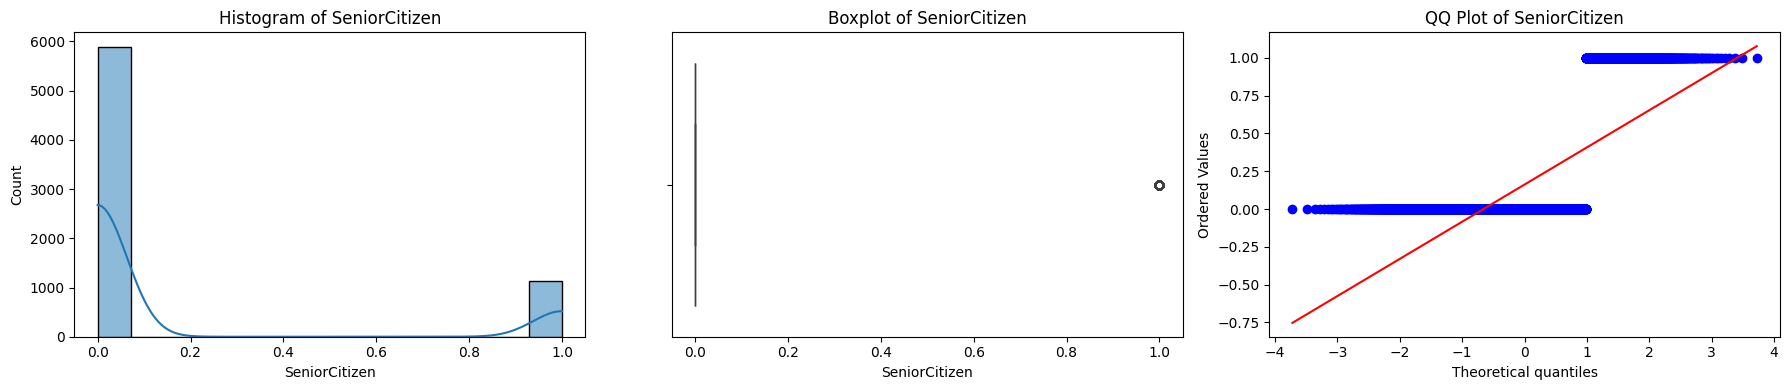

In [18]:
showHistBoxQQ("SeniorCitizen")

<div class="alert alert-info" role="alert">SeniorCitizen shows binary values with only 0s and 1s, so it should be converted into a categorical variable.</div>

### Tenure

Figure(1800x400)


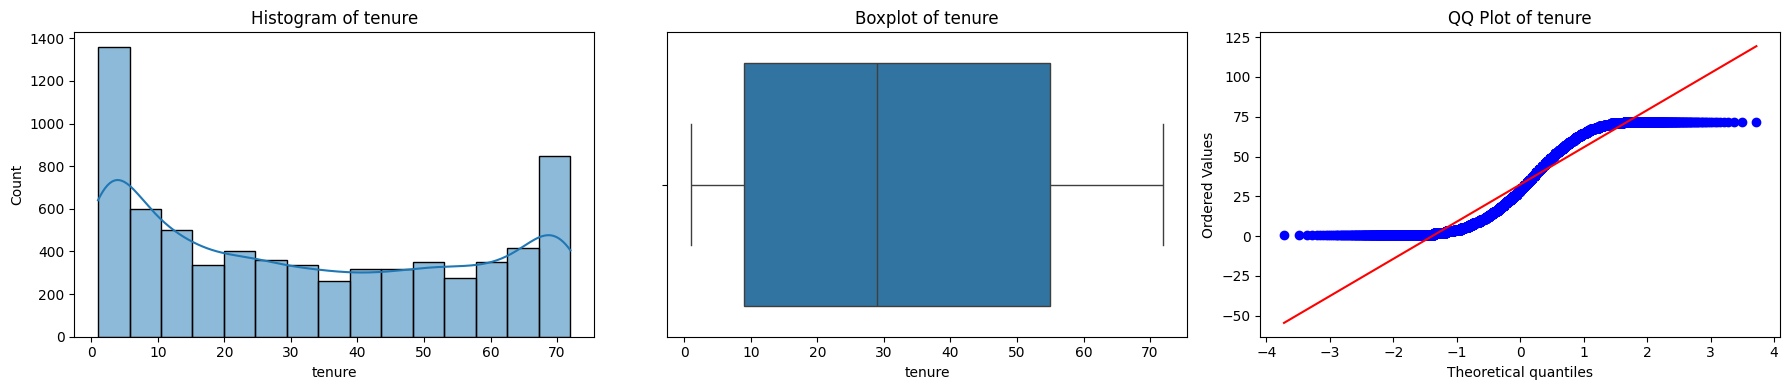

In [19]:
showHistBoxQQ("tenure")

<div class="alert alert-info" role="alert">tenure is right-skewed with a long tail of loyal customers, so applying a log transformation or binning into tenure groups, followed by scaling is appropriate.</div>

### MonthlyCharges

Figure(1800x400)


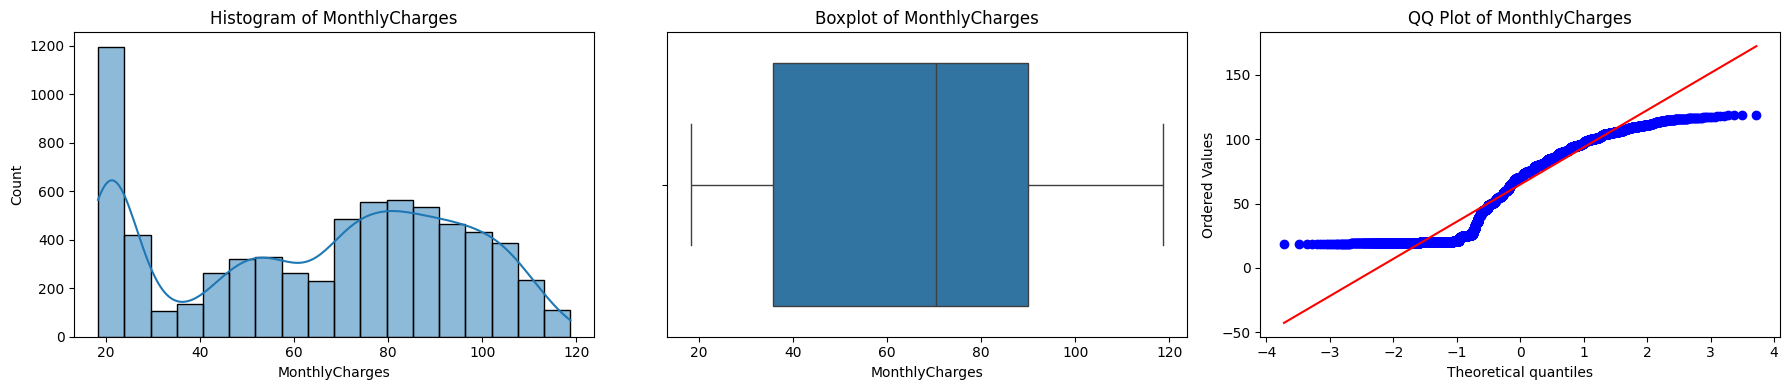

In [20]:
showHistBoxQQ("MonthlyCharges")

<div class="alert alert-info" role="alert">MonthlyCharges has a slightly bimodal distribution and moderate skew, so it should be scaled or binned into pricing tiers.</div>

### CLTV

Figure(1800x400)


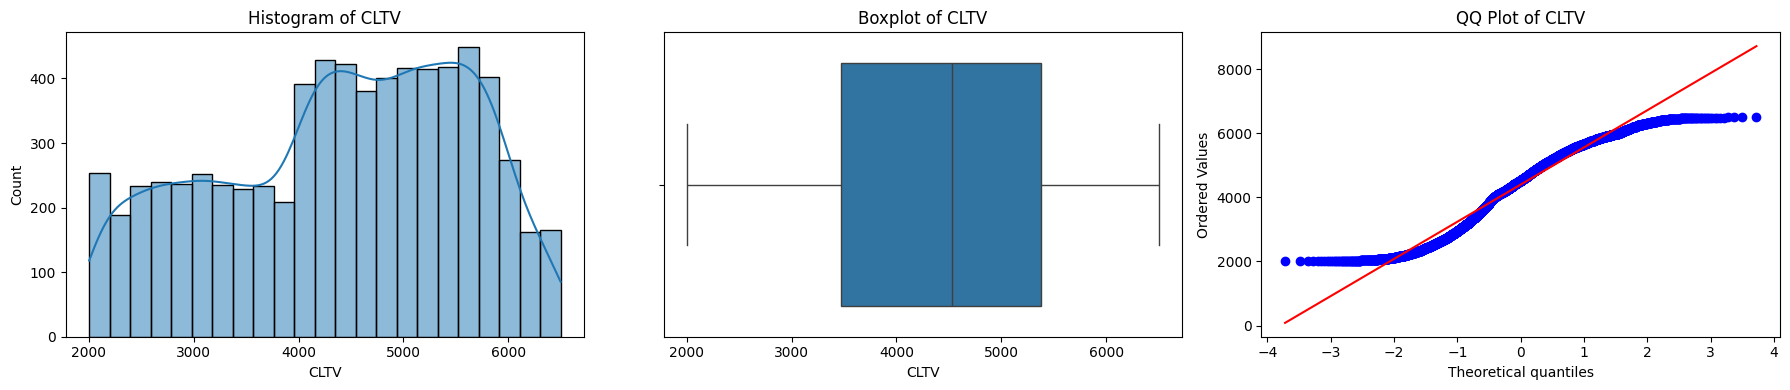

In [21]:
showHistBoxQQ("CLTV")

<div class="alert alert-info" role="alert">CLTV shows a wide spread and moderate skew, making it suitable for an optional log transformation, followed by scaling.</div>

### Satisfaction Score

Figure(1800x400)


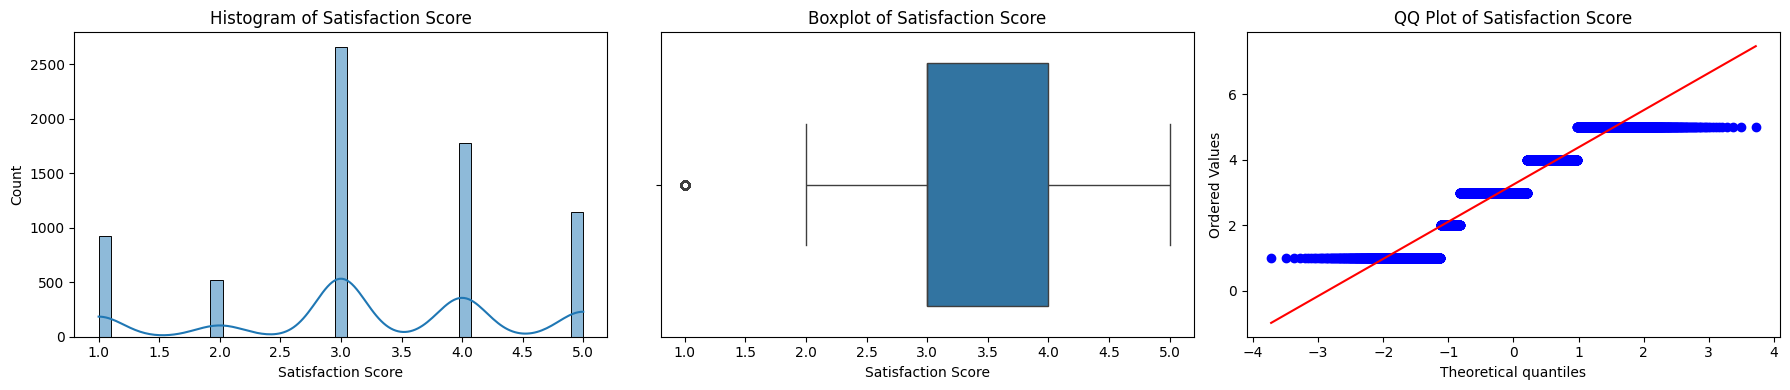

In [22]:
showHistBoxQQ("Satisfaction Score")

<div class="alert alert-info" role="alert">Satisfaction Score is clearly ordinal with values ranging from 1 to 5, so it should be encoded using an ordinal encoding scheme.</div>

**To do:**
1. `SeniorCitizen` → Binary (0/1), convert to **categorical**
1. `tenure` → Right-skewed; apply **log transform or bin**, then **scale**
1. `MonthlyCharges` → Slightly bimodal and skewed; **scale** or **bin into pricing tiers**
1. `CLTV` → Moderately skewed and spread out; optionally apply **log transform**, then **scale**
1. `Satisfaction Score` → Ordinal values (1–5); apply **ordinal encoding**

## Data Correlation (Nominal and Ratio scale correlation)

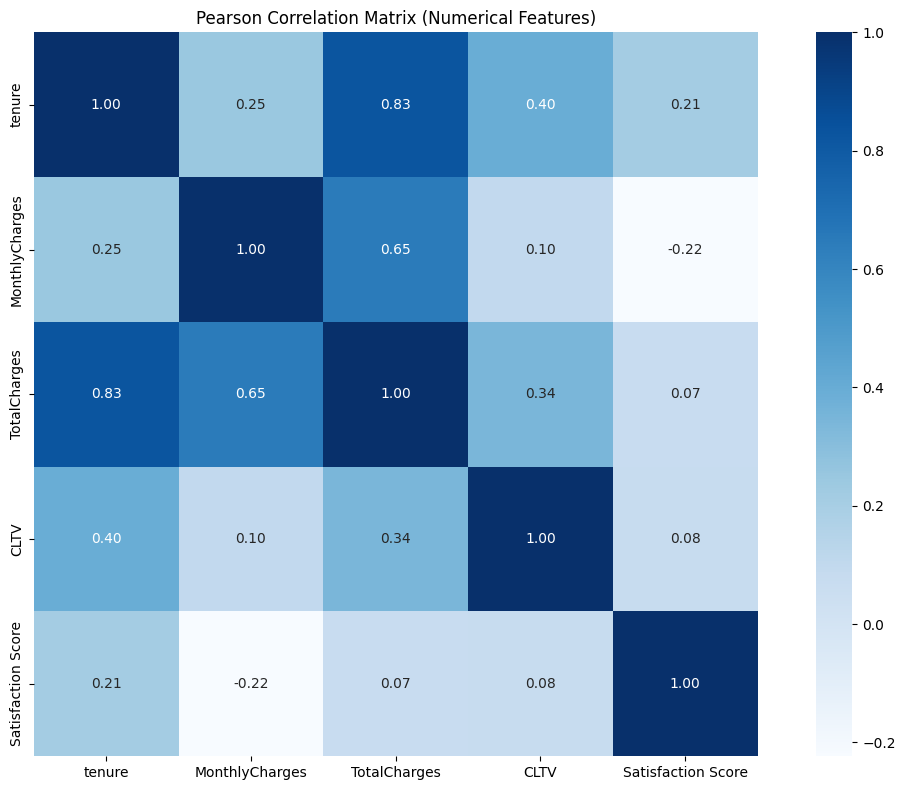

In [23]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute Pearson correlation matrix
pearson_corr = df[numerical_features].corr(method="pearson")

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pearson_corr, annot=True, cmap="Blues", fmt=".2f", square=True)
plt.title("Pearson Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

**To do:**  REVISI
1. `tenure` & `CLTV` → keep both; consider **feature interaction**
1. `MonthlyCharges` & `tenure` → keep both; **scale**
1. `SeniorCitizen` & `MonthlyCharges` → explore **interaction**
1. `Satisfaction Score` & `MonthlyCharges` → consider **feature interaction**
1. Most other correlations → **no action needed**

---

# Split Data
---

In [26]:
df = df[
    [
        "customerID",
        "gender",
        "AgeGroup",
        "Partner",
        "CLTV",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "PaperlessBilling",
        "PaymentMethod",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn Reason",
        "Churn",
    ]
]

In [27]:
train, test = train_test_split(df, test_size=0.2, stratify=df["Churn"], random_state=42)

<div class="alert alert-info" role="alert">Split train test 80% with train_test_split.<div></div>

In [28]:
train

,customerID,gender,AgeGroup,Partner,CLTV,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Contract,Churn Reason,Churn
1413,1830-GGFNM,Male,Middle Age (30–59),True,4603,True,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,False,Credit card (automatic),65,94.55,6078.75,Two year,-,False
7003,4501-VCPFK,Male,Under 30,False,2734,False,No phone service,DSL,No,No,Yes,Yes,No,No,False,Electronic check,26,35.75,1022.50,Month-to-month,-,False
3355,8871-JLMHM,Female,Under 30,True,4095,True,Yes,Fiber optic,No,Yes,Yes,Yes,No,No,False,Credit card (automatic),68,90.20,6297.65,Two year,-,False
4494,0225-ZORZP,Male,Middle Age (30–59),False,5828,True,No,Fiber optic,No,Yes,No,No,No,Yes,False,Electronic check,3,84.30,235.05,Month-to-month,-,False
3541,1530-ZTDOZ,Female,Middle Age (30–59),True,5565,False,No phone service,DSL,Yes,No,No,No,Yes,No,False,Bank transfer (automatic),49,40.65,2070.75,Month-to-month,-,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,5397-TUPSH,Male,Senior (≥ 60),True,4871,True,No,Fiber optic,No,No,No,No,No,No,True,Bank transfer (automatic),65,70.95,4555.20,One year,-,False
5123,8020-BWHYL,Female,Senior (≥ 60),False,4526,True,No,Fiber optic,No,Yes,No,No,No,No,True,Credit card (automatic),15,75.30,1147.45,Month-to-month,Competitor offered more data,True
4135,8670-MEFCP,Female,Under 30,True,3570,True,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,True,Credit card (automatic),36,92.90,3379.25,Two year,-,False
4249,7919-ZODZZ,Female,Middle Age (30–59),True,5289,True,No,DSL,No,Yes,Yes,No,No,Yes,True,Mailed check,10,65.90,660.05,One year,-,False


In [29]:
test

,customerID,gender,AgeGroup,Partner,CLTV,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Contract,Churn Reason,Churn
974,0604-THJFP,Female,Middle Age (30–59),True,5446,True,No,DSL,No,Yes,No,Yes,Yes,Yes,True,Credit card (automatic),59,75.95,4542.35,Two year,-,False
619,4059-IIEBK,Female,Middle Age (30–59),False,4025,True,Yes,Fiber optic,No,Yes,No,No,No,No,True,Bank transfer (automatic),7,78.55,522.95,Month-to-month,-,False
4289,2228-BZDEE,Female,Middle Age (30–59),False,5755,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,False,Mailed check,54,20.10,1079.45,Two year,-,False
3721,2839-RFSQE,Female,Middle Age (30–59),False,3845,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,False,Mailed check,2,20.65,38.70,Month-to-month,Attitude of support person,True
4533,5360-LJCNJ,Female,Middle Age (30–59),True,5707,True,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,True,Bank transfer (automatic),71,105.15,7555.00,Two year,-,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4829,1600-DILPE,Female,Middle Age (30–59),False,4998,True,No,DSL,No,No,No,No,No,No,True,Bank transfer (automatic),12,45.00,524.35,Month-to-month,-,False
5176,0128-MKWSG,Female,Middle Age (30–59),False,3287,False,No phone service,DSL,Yes,No,No,Yes,No,Yes,False,Mailed check,26,45.80,1147.00,Month-to-month,-,False
2750,1179-INLAT,Male,Middle Age (30–59),False,2787,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,True,Mailed check,3,19.45,69.25,One year,-,False
4432,3891-NLXJB,Male,Under 30,False,4050,False,No phone service,DSL,Yes,Yes,No,Yes,No,No,True,Mailed check,37,40.55,1390.85,Two year,-,False


In [31]:
# Save data set
# train.to_csv("Dataset/train_telco.csv", index=False)
# test.to_csv("Dataset/test_telco.csv", index=False)

Di comment biar ga berubah csvnya

---

# Methodology (Data Analytics)
---

<div class="alert alert-info" role="alert">Train Telco Customer Churn Data set.</div>

In [32]:
df = pd.read_csv("Dataset/train_telco.csv")
df.sample(5)

,customerID,gender,AgeGroup,Partner,CLTV,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Contract,Churn Reason,Churn
3007,6356-ELRKD,Female,Under 30,False,4091,True,No,Fiber optic,Yes,No,No,No,Yes,Yes,True,Electronic check,1,95.60,95.60,Month-to-month,Don't know,True
2563,9777-IQHWP,Male,Middle Age (30–59),True,6249,True,Yes,Fiber optic,Yes,No,Yes,No,No,Yes,False,Bank transfer (automatic),64,93.40,5822.30,Two year,-,False
3730,6169-PGNCD,Female,Middle Age (30–59),False,5741,True,No,DSL,Yes,Yes,Yes,Yes,Yes,No,True,Credit card (automatic),57,74.30,4166.35,Two year,-,False
5336,0234-TEVTT,Female,Middle Age (30–59),True,5269,False,No phone service,DSL,Yes,No,Yes,No,No,Yes,False,Credit card (automatic),48,45.00,2196.30,One year,-,False
3434,9560-BBZXK,Female,Middle Age (30–59),False,4871,False,No phone service,DSL,Yes,No,No,No,No,No,False,Bank transfer (automatic),36,31.05,1126.35,Two year,-,False


## Analysis Paradigm

### Descriptive Analysis

#### Numerical Feature

##### 1. Churn Distribution

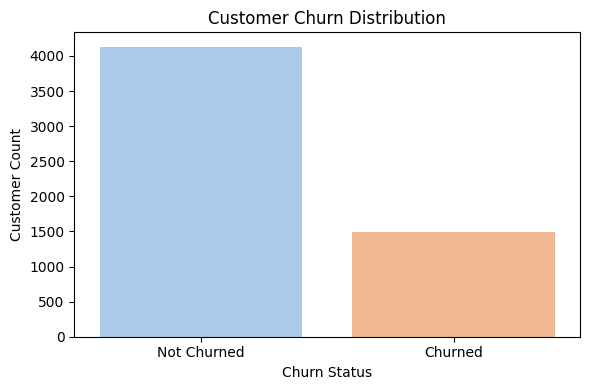

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='pastel')
plt.title("Customer Churn Distribution")
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">It shows that a significant portion of customers have churned, though the majority have not. This highlights the importance of customer retention as a business priority.</div>

##### 2. Tenure Distribution by Churn

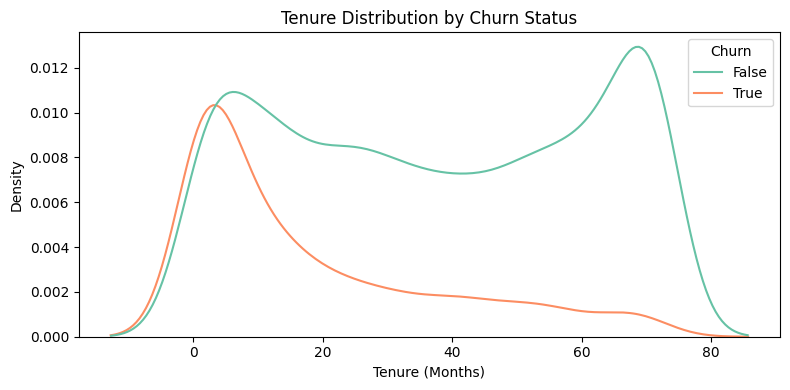

In [34]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="tenure", hue="Churn", palette='Set2')
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">Churned customers are concentrated in the early tenure (0–15 months). Longer-term customers are more stable. This suggests the need to focus on new customer engagement to reduce churn.</div>

##### 3. Monthly Charges by Churn

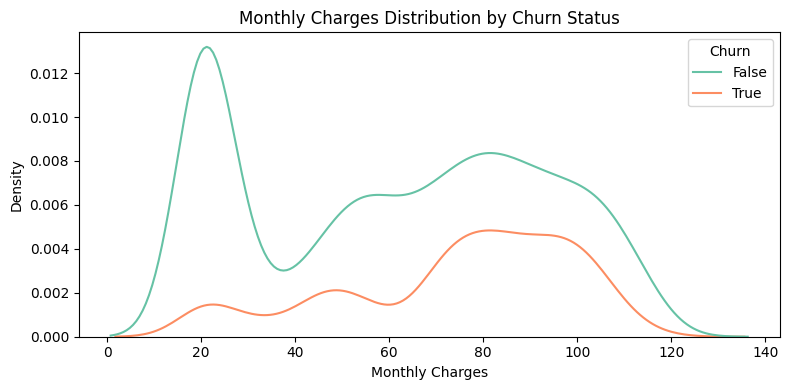

In [35]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", palette='Set2')
plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">Customers with higher monthly charges are more likely to churn. This suggests dissatisfaction with value or affordability and hints that pricing restructuring or bundling could reduce churn.</div>

##### 4. Total Charges by Churn

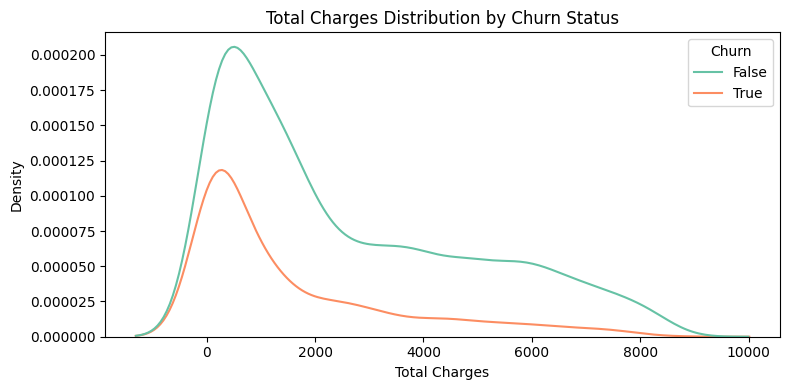

In [36]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="TotalCharges", hue="Churn", palette='Set2')
plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">Churned customers generally have lower total charges, showing they leave early. Non-churned customers have higher cumulative spend, confirming they’re long-term users and more profitable.</div>

#### Categorical Feature

##### 1. Contact Type vs. Churn

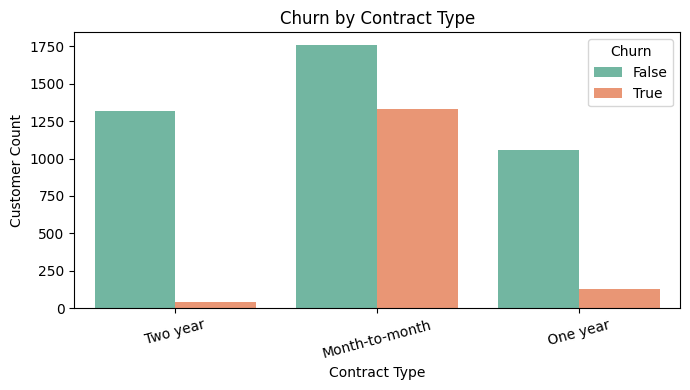

In [37]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Month-to-month customers churn the most</li>
        <li>Customers with 1 or 2-year contracts churn far less, likely due to commitment or penalties for early termination</li>
        <li><b>Promote long-term contracts with incentives</b></li>
    </ul>
</div>

##### 2. Payment Method vs. Churn

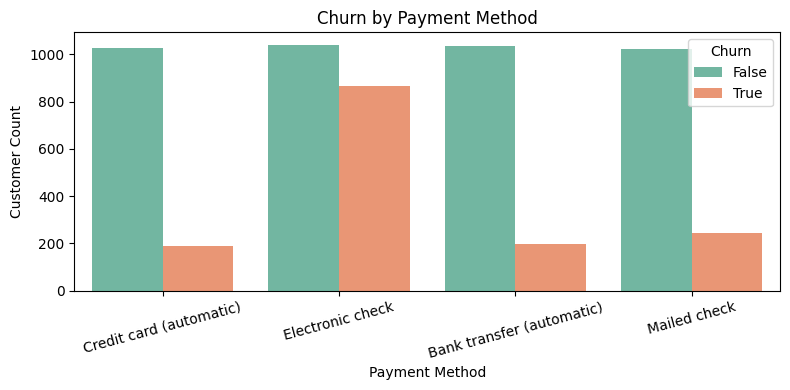

In [38]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Electronic check users churn the most</li>
        <li>Other digital methods (Credit card, Bank transfer) show lower churn</li>
        <li><b>Suggests that payment friction or billing reliability may affect churn</b></li>
    </ul>
</div>

##### 3. Internet Service vs. Churn

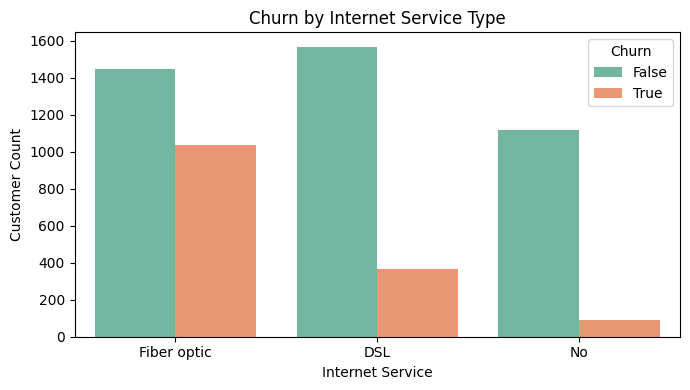

In [39]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Fiber optic customers churn the most—possibly due to higher cost or unmet speed expectations</li>
        <li><b>No internet service customers churn least</b></li>
    </ul>
</div>

##### 4. Tech Support vs. Churn

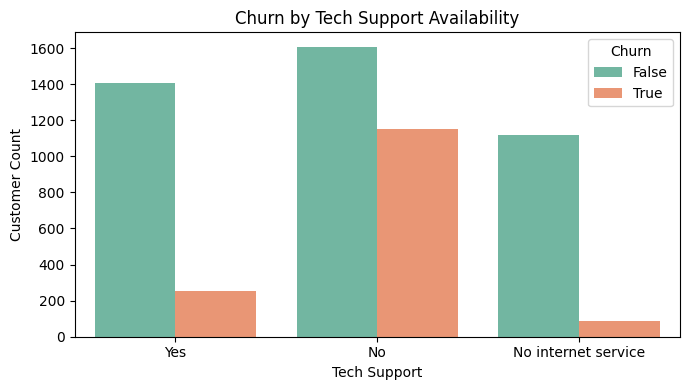

In [40]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Set2')
plt.title('Churn by Tech Support Availability')
plt.xlabel('Tech Support')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Customers without tech support churn heavily</li>
        <li>Those with active support are more loyal</li>
        <li><b>Suggests tech support can improve customer retention</b></li>
    </ul>
</div>

##### 5. Online Security vs. Churn

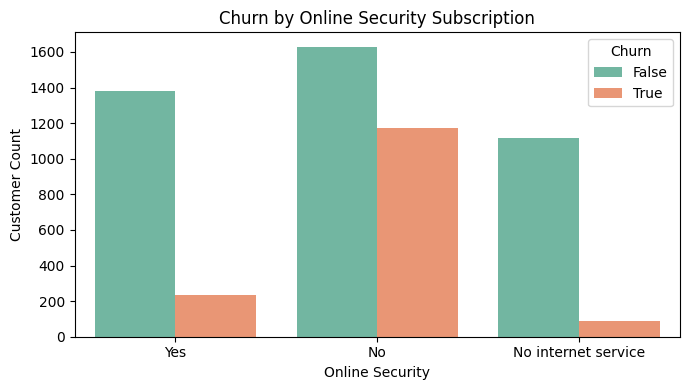

In [41]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='Set2')
plt.title('Churn by Online Security Subscription')
plt.xlabel('Online Security')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Customers without security churn more</li>
        <li>Those with Online Security activated stay longer</li>
        <li><b>Bundling value-added services could reduce churn</b></li>
    </ul>
</div>

##### 6. Age Group vs. Churn

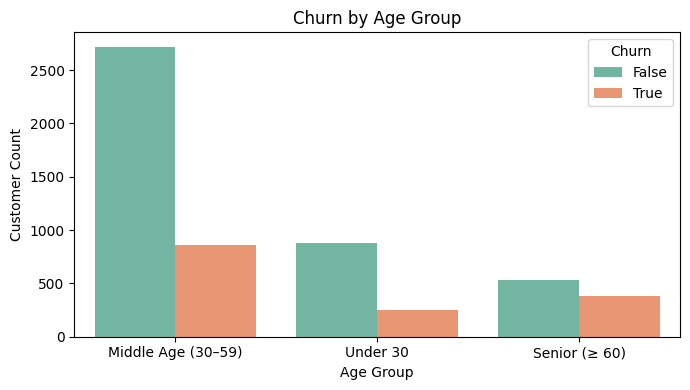

In [42]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='AgeGroup', hue='Churn', palette='Set2')
plt.title('Churn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>All age groups experience churn, but senior users (>=60) may churn slightly more</li>
        <li><b>Middle-aged and older customers tend to be slightly more stable</b></li>
    </ul>
</div>

##### 7. Streaming TV vs. Churn

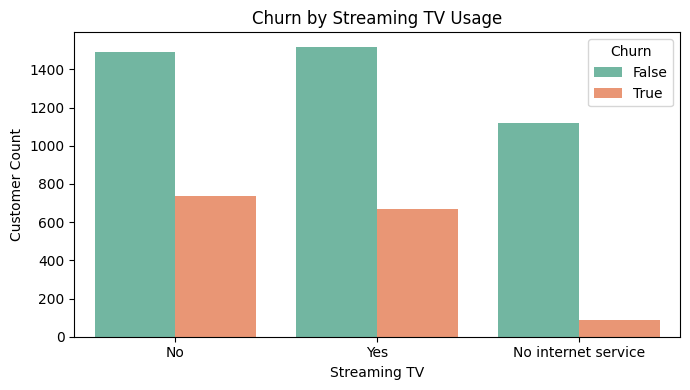

In [43]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='StreamingTV', hue='Churn', palette='Set2')
plt.title('Churn by Streaming TV Usage')
plt.xlabel('Streaming TV')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Both users and non-users of Streaming TV churn, but those with no access seem more likely to churn</li>
        <li><b>Customers using this feature are more retained, possibly due to added value</b></li>
    </ul>
</div>

##### 8. Device Protection vs. Churn

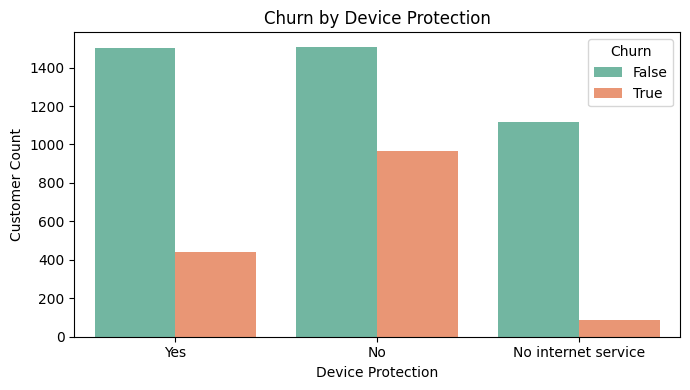

In [44]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='DeviceProtection', hue='Churn', palette='Set2')
plt.title('Churn by Device Protection')
plt.xlabel('Device Protection')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Customers without protection churn more</li>
        <li><b>Offering these features may encourage long-term commitment</b></li>
    </ul>
</div>

##### 9. Online Backup vs. Churn

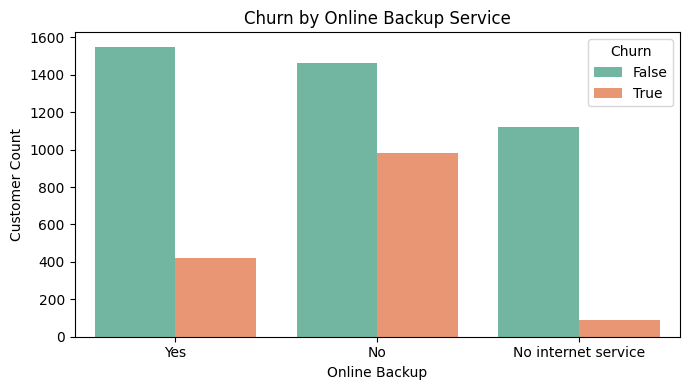

In [45]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='OnlineBackup', hue='Churn', palette='Set2')
plt.title('Churn by Online Backup Service')
plt.xlabel('Online Backup')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Customers with backup show more loyalty</li>
        <li><b>Encouraging backup subscriptions may reduce risk of churn</b></li>
    </ul>
</div>

##### 10. Paperless Billing vs. Churn

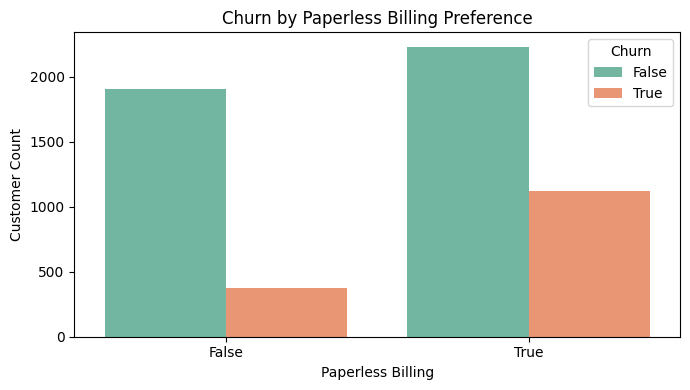

In [46]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='PaperlessBilling', hue='Churn', palette='Set2')
plt.title('Churn by Paperless Billing Preference')
plt.xlabel('Paperless Billing')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    <ul>
        <li>Paperless billing customers churn more</li>
        <li><b>Could be an indicator of lower service attachment, or demographic effect (example: AgeGroup)</b></li>
    </ul>
</div>

### Inferential Analysis

#### T-Test for Numerical Features

In [47]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLTV']
ttest_results = []

for col in numerical_cols:
    churned = df[df['Churn'] == True][col]
    not_churned = df[df['Churn'] == False][col]
    t_stat, p = ttest_ind(churned, not_churned, equal_var=False)
    ttest_results.append({
        'Feature': col,
        't-statistic': round(t_stat, 2),
        'p-value': round(p, 4),
        'Significant (p < 0.05)': p < 0.05
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,Feature,t-statistic,p-value,Significant (p < 0.05)
0,tenure,-30.88,0.0,True
1,MonthlyCharges,16.42,0.0,True
2,TotalCharges,-16.61,0.0,True
3,CLTV,-9.37,0.0,True


<div class="alert alert-danger" role="alert">
    <ul>
        <li><b>Tenure & TotalCharges:</b> Lower for churned customers — they leave early and spend less</li>
        <li><b>MonthlyCharges:</b> Higher for churned customers — they pay more each month</li>
        <li><b>CLTV:</b> Lower for churners — churned users are less profitable long-term</li>
    </ul>
</div>

#### Chi-Square Test for Categorical Features

In [48]:
categorical_cols = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 
                    'OnlineSecurity', 'AgeGroup', 'StreamingTV', 'DeviceProtection', 
                    'OnlineBackup', 'PaperlessBilling']
chi2_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({
        'Feature': col,
        'Chi2 Statistic': round(chi2, 2),
        'p-value': round(p, 4),
        'Significant (p < 0.05)': p < 0.05
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df

,Feature,Chi2 Statistic,p-value,Significant (p < 0.05)
0,Contract,972.62,0.0,True
1,PaymentMethod,529.90,0.0,True
2,InternetService,579.94,0.0,True
3,TechSupport,661.78,0.0,True
4,OnlineSecurity,688.13,0.0,True
5,AgeGroup,129.91,0.0,True
6,StreamingTV,294.18,0.0,True
7,DeviceProtection,439.78,0.0,True
8,OnlineBackup,489.00,0.0,True
9,PaperlessBilling,199.03,0.0,True


<div class="alert alert-danger">All tested features have p-values less than 0.05, meaning their influence on churn is <b>unlikely</b> due to random chance</div>

## Analysis Structure

### 5W1H Framework
| Category | Explanation                                                                                                                         |
|----------|-------------------------------------------------------------------------------------------------------------------------------------|
| Who      | Customers with month-to-month contracts, using fiber optic internet, and lacking support/security features are more likely to churn |
| What     | Churners tend to have short tenure, higher monthly charges, and lower total/lifetime value                                          |
| When     | Most churn happens within the first 6-15 months of tenure                                                                             |
| Where    | Location data not available in this                                                                                                 |
| Why      | Customers may perceive high cost and low value, leading them to cancel easily                                                       |
| How      | They feel underserved and are more prone to exit before becoming profitable                                                         |

### Insight Narration For Churn Analysis
| Insight | Narration                                                                                                                         |
|----------|-------------------------------------------------------------------------------------------------------------------------------------|
| Short Tenure, High Risk      | Customers who churn typically leave within the first 6-15 months, showing that early engagement is critical |
| Premium Bills Without Perceived Value     | Churned customers often pay higher monthly charges but have lower total spend, indicating that they exit before long-term value is captured                                          |
| Support Services Reduce Churn     | Users without tech support, online backup, or device protection are more likely to churn, implying these services provide retention value                                                                             |
| Contract Length Protects Retention    | Month-to-month contracts are linked with high churn, while long-term contracts reduce exit likelihood due to commitment or incentive                                                                                                 |
| Digital Payment Methods Signal Risk      | Customers paying with electronic checks show higher churn rates, which may reflect disengagement or payment friction                                                       |

### Quantitative Principle - Supporting Digital Payment Churn Insight
| Insight                                | Quantitative Principle                                                                            |
| -------------------------------------- | ------------------------------------------------------------------------------------------------- |
| Short Tenure, High Risk            | T-test confirms tenure is much lower for churned customers (t = -30.88, p < 0.05)                 |
| Premium Bills Without Value        | Churned customers pay more monthly but generate less total revenue supported by t-tests         |
| Support Services Reduce Churn      | Chi-square test shows churn is significantly higher for users without support/protection features |
| Contract Length Protects Retention | Contract type is statistically tied to churn (p < 0.05), especially for month-to-month users      |
| Digital Payment Risk               | Chi-square test validates churn is concentrated among electronic check users                      |

### Actionable Insights For Churn Reduction

| Insight                               | Actionable Strategy                                                                     |
| ------------------------------------- | --------------------------------------------------------------------------------------- |
| Short Tenure, High Risk           | Implement targeted onboarding programs and check-ins during the first 6-15 months to reduce early churn      |
| Premium Bills Without Value       | Bundle high-cost plans with value-added features to justify price and reduce perceived overcharging       |
| Support Services Reduce Churn     | Promote and upsell tech support, online backup, and protection services to increase retention     |
| Contract Length Retains           | Offer discounts or loyalty rewards for customers switching from month-to-month to long-term contracts |
| Payment Risk via Electronic Check | Monitor and intervene with customers using electronic checks via personalized outreach or incentives           |


## Expected Analysis Results

### Short Tenure, High Risk

In [76]:
short_tenure_customers = df[(df['tenure'] >= 6) & (df['tenure'] <= 15)]

list_short_tenure = short_tenure_customers[[
    'customerID', 'AgeGroup', 'tenure'
]]

display(list_short_tenure)

,customerID,AgeGroup,tenure
6,7319-VENRZ,Under 30,7
9,9239-ZBZZV,Under 30,6
11,6400-BWQKW,Middle Age (30–59),6
12,8104-OSKWT,Middle Age (30–59),12
22,5384-ZTTWP,Middle Age (30–59),15
...,...,...,...
5587,7665-VIGUD,Middle Age (30–59),10
5597,0236-HFWSV,Middle Age (30–59),15
5601,1729-VLAZJ,Middle Age (30–59),10
5621,8020-BWHYL,Senior (≥ 60),15


<div class="alert alert-info" role="alert">
    We can ask the tech support team or customer service to contact customers with a tenure of 6 to 15 months to address any problems or difficulties they may be experiencing with the program they are using
</div>

### Premium Bills Without Value & Support Services Reduce Churn

In [71]:
high_cost_threshold = df['MonthlyCharges'].quantile(0.75)

high_cost_customers = df[df['MonthlyCharges'] > high_cost_threshold]

# Group by presence of value-added services
value_services = ['TechSupport', 'OnlineSecurity', 'StreamingTV']
summary_table = (
    high_cost_customers
    .groupby(value_services)
    .agg(
        Customers=('customerID', 'count'),
        Churn_Rate=('Churn', 'mean')
    )
    .reset_index()
)

summary_table['Churn_Rate'] = (summary_table['Churn_Rate'] * 100).round(1).astype(str) + '%'
summary_table

,TechSupport,OnlineSecurity,StreamingTV,Customers,Churn_Rate
0,No,No,No,38,31.6%
1,No,No,Yes,504,52.4%
2,No,Yes,No,50,26.0%
3,No,Yes,Yes,188,25.5%
4,Yes,No,No,36,13.9%
5,Yes,No,Yes,278,29.9%
6,Yes,Yes,No,54,11.1%
7,Yes,Yes,Yes,252,14.7%


<div class="alert alert-info" role="alert">
    Since number 1 has the highest mean churn rate (52.4%), we can assume it represents a high-cost plan. Additionally, since the majority of customers who bundle with tech support have a low churn rate, we suggest offering customers in group number 1 a promotional offer to include tech support in their bundle
</div>

In [78]:
customer_high_cost_bundle = df[
    (df['MonthlyCharges'] > high_cost_threshold) &
    (df['TechSupport'] == 'No') &
    (df['OnlineSecurity'] == 'No') &
    (df['StreamingTV'] == 'Yes')
]

list_high_cost_bundle = customer_high_cost_bundle[[
    'customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'CLTV',
    'Contract', 'PaymentMethod'
]]

list_high_cost_bundle.sample(5)

,customerID,tenure,MonthlyCharges,TotalCharges,CLTV,Contract,PaymentMethod
1576,3269-ATYWD,39,95.65,3759.05,4892,Month-to-month,Bank transfer (automatic)
2896,4958-XCBDQ,35,101.40,3496.30,3689,Month-to-month,Electronic check
4311,2927-QRRQV,46,94.65,4312.50,4120,One year,Electronic check
5517,7028-DVOIQ,35,99.05,3395.80,2074,Month-to-month,Electronic check
4347,2840-XANRC,24,93.15,2231.05,2212,Month-to-month,Electronic check


<div class="alert alert-info" role="alert">
    By targeting customers subscribed to the most frequently churned bundles, we can offer a promotional incentive to include tech support in their plans an approach likely to improve retention
</div>

### Contract Length Retains

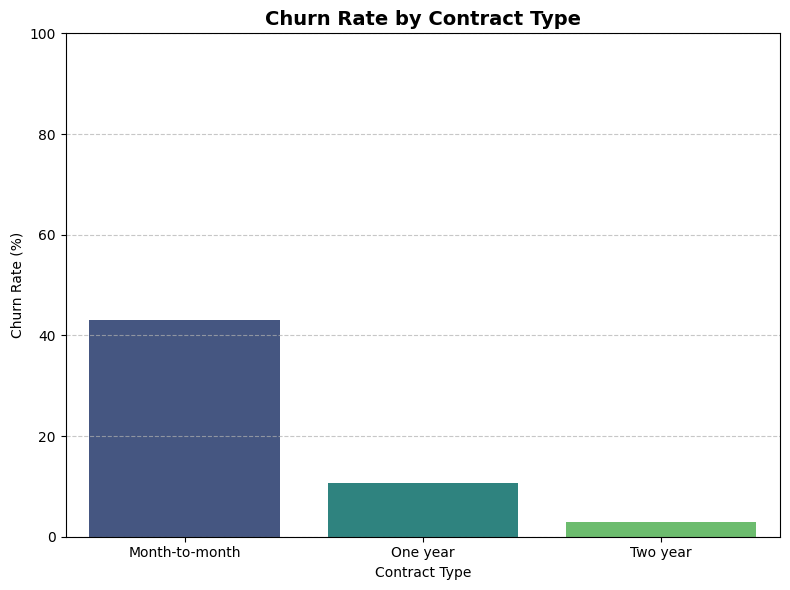

In [82]:
contract_churn = (
    df.groupby('Contract')
    .agg(
        Customer_Count=('customerID', 'count'),
        Churn_Rate=('Churn', 'mean')
    )
    .reset_index()
)

contract_churn['Churn_Rate'] = contract_churn['Churn_Rate'] * 100

plt.figure(figsize=(8, 6))
sns.barplot(data=contract_churn, x='Contract', y='Churn_Rate', palette='viridis')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    We can suggest that prospective customers choose longer-term contracts, as the data shows that longer contracts are associated with lower churn rates
</div>

### Payment Risk via Electronic Check

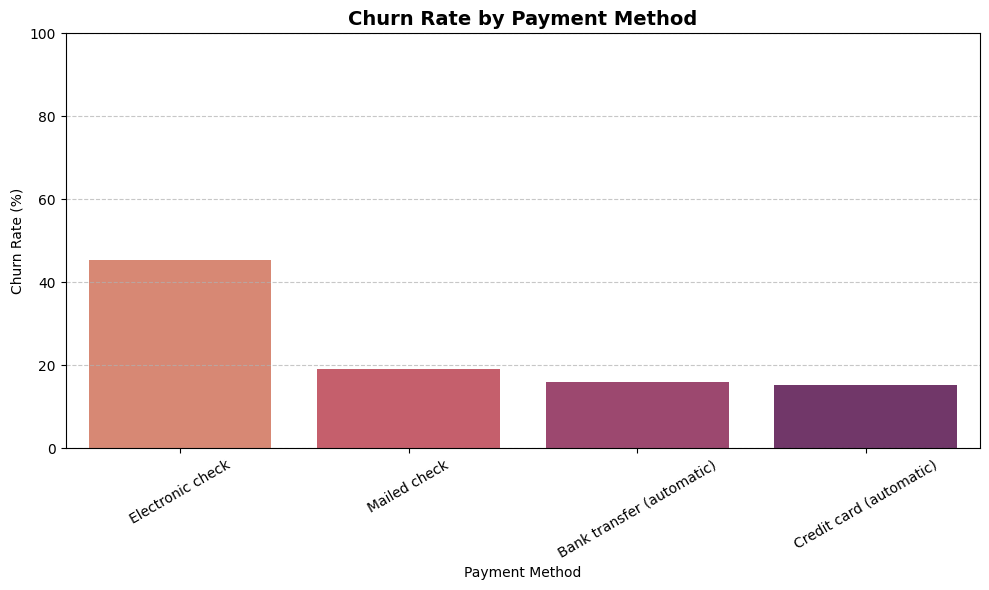

In [90]:
payment_churn = (
    df.groupby('PaymentMethod')
    .agg(
        Customer_Count=('customerID', 'count'),
        Churn_Rate=('Churn', 'mean')
    )
    .reset_index()
)

payment_churn['Churn_Rate'] = payment_churn['Churn_Rate'] * 100
payment_churn = payment_churn.sort_values(by="Churn_Rate", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Rate', palette='flare')
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div class="alert alert-info" role="alert">
    
</div>

---

# Methodology (Machine Learning)
---

In [47]:
# Train Telco Customer Churn Data set
# df = pd.read_csv("Dataset/train_telco.csv")
# df.sample(5)

---